In [15]:
import torch
from torchvision.io import decode_image
import numpy as np

import matplotlib.pyplot as plt


In [29]:
import torch

def radial_power_spectrum(image):
    # 1. Ensure input is 4D: (Batch, Channels, Height, Width)
    if image.dim() == 3:
        image = image.unsqueeze(0)
    
    B, C, H, W = image.shape
    
    # 2. Compute 2D FFT and shift center
    # Note: Only apply fft and shift over the spatial dimensions (-2, -1)
    f_coeffs = torch.fft.fft2(image, dim=(-2, -1))
    f_shifted = torch.fft.fftshift(f_coeffs, dim=(-2, -1))
    
    # 3. Calculate Power Spectrum: |F(u,v)|^2
    power_2d = torch.abs(f_shifted)**2
    
    # Average the power across channels (standard practice for image/latent PSD)
    # New shape: (B, H, W)
    power_2d = power_2d.mean(dim=1) 
    
    # 4. Create radial coordinate grid
    yc, xc = H // 2, W // 2
    y, x = torch.meshgrid(torch.arange(H) - yc, torch.arange(W) - xc, indexing='ij')
    r = torch.sqrt(x**2 + y**2).to(image.device)
    
    # 5. Binning setup
    r_int = r.round().long()
    max_r = int(min(H, W) / 2)
    
    # Mask out corners of the square image where radius > max_r
    valid_mask = r_int <= max_r
    
    # 6. Accumulate power per radius, per batch
    psd_1d = torch.zeros(B, max_r + 1, device=image.device)
    counts = torch.zeros(max_r + 1, device=image.device)
    
    # Flatten spatial dims to use scatter_add
    # power_flat: (B, H*W) | r_flat: (H*W)
    power_flat = power_2d.view(B, -1)
    r_flat = r_int.flatten()
    
    # We only want to scatter valid radii (ignore corners)
    r_valid = r_flat[valid_mask.flatten()]
    power_valid = power_flat[:, valid_mask.flatten()]
    
    # Scatter add along the spatial dimension (dim=1)
    # r_valid needs to be expanded to match batch size for scatter_add
    r_expanded = r_valid.unsqueeze(0).expand(B, -1)
    psd_1d.scatter_add_(1, r_expanded, power_valid)
    
    # Count the number of pixels at each radius (only need to do this once, not per batch)
    counts.scatter_add_(0, r_valid, torch.ones_like(r_valid, dtype=torch.float32))
    
    # 7. Normalize by counts to get the expectation (mean)
    # Add a tiny epsilon to prevent division by zero for empty bins
    psd_1d = psd_1d / (counts.unsqueeze(0) + 1e-8)
    
    return psd_1d

def plot_psd_1d(psd_1d, sample_idx=0):
    # psd_1d shape is (Batch, Max_R)
    psd_to_plot = psd_1d[sample_idx].cpu().numpy()
    
    # Create frequency axis (0 to 0.5 cycles/pixel is standard)
    freqs = np.arange(len(psd_to_plot))
    
    plt.figure(figsize=(8, 5))
    plt.loglog(freqs, psd_to_plot, label=f"Sample {sample_idx}")
    
    plt.title("Radially Averaged Power Spectral Density")
    plt.xlabel("Frequency (Radius in pixels)")
    plt.ylabel("Power (Log Scale)")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()
    
def plot_multiple_psd_1d(psd_dict, sample_idx=0):
    plt.figure(figsize=(10, 6))
    
    for label, psd_1d in psd_dict.items():
        psd_to_plot = psd_1d[sample_idx].cpu().numpy()
        
        # Start at 1 to avoid log(0) for the DC component (mean of the image)
        freqs = np.arange(1, len(psd_to_plot))
        psd_to_plot = psd_to_plot[1:] 
        
        plt.loglog(freqs, psd_to_plot, label=label, linewidth=2)
    
    plt.title("Radially Averaged Power Spectral Density (Log-Log)", fontsize=14)
    plt.xlabel("Frequency (Radius in pixels)", fontsize=12)
    plt.ylabel("Power", fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=12)
    plt.show()

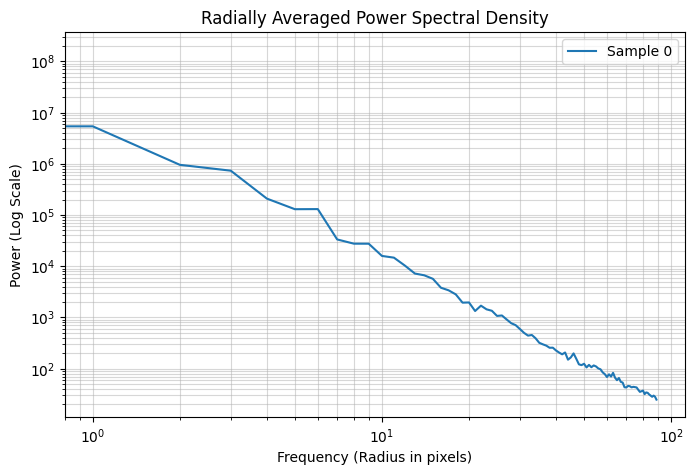

In [30]:
image_path = "./images/000010.jpg"
img_tensor = decode_image(image_path)
img_tensor = img_tensor.float() / 255.0

rps = radial_power_spectrum(img_tensor)
plot_psd_1d(rps)

#### For natural images, PSD follows a staight line, power law distribution

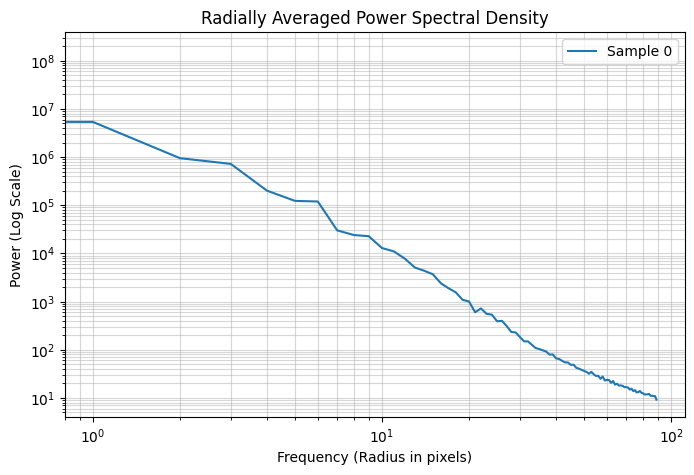

In [31]:
image_path = "./images/000010_blurred.jpg"
img_tensor = decode_image(image_path)
img_tensor = img_tensor.float() / 255.0

rps = radial_power_spectrum(img_tensor)
plot_psd_1d(rps)

#### Blurring the image reduces high frequency components, so the PSD drops off more steeply at higher frequencies.

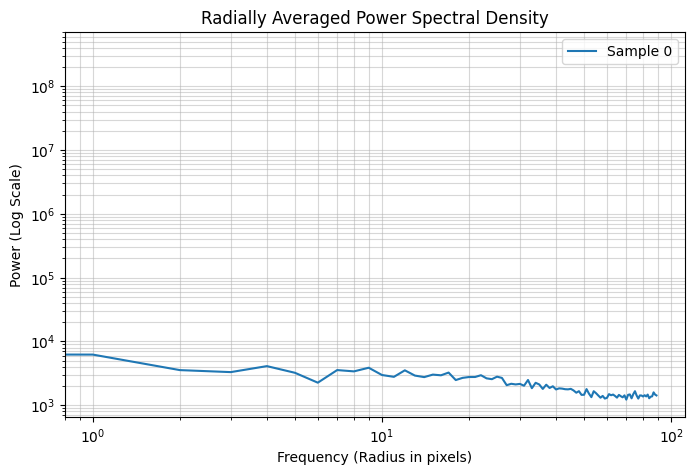

In [32]:
image_path = "./images/random_image.jpg"
img_tensor = decode_image(image_path)
img_tensor = img_tensor.float() / 255.0

rps = radial_power_spectrum(img_tensor)
plot_psd_1d(rps)

#### For a random image, the PSD is relatively flat across frequencies, indicating no dominant spatial structure or correlation.

## PSD of VAE

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from diffusers import AutoencoderKL

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Using device: mps
Loading VAE...


/Users/pahautelman/uni/master/DSAIT4030 Generative Modelling/spectrum-matching-project/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Encoding Image...
Image shape: torch.Size([1, 3, 512, 512])
Latent shape: torch.Size([1, 4, 64, 64])


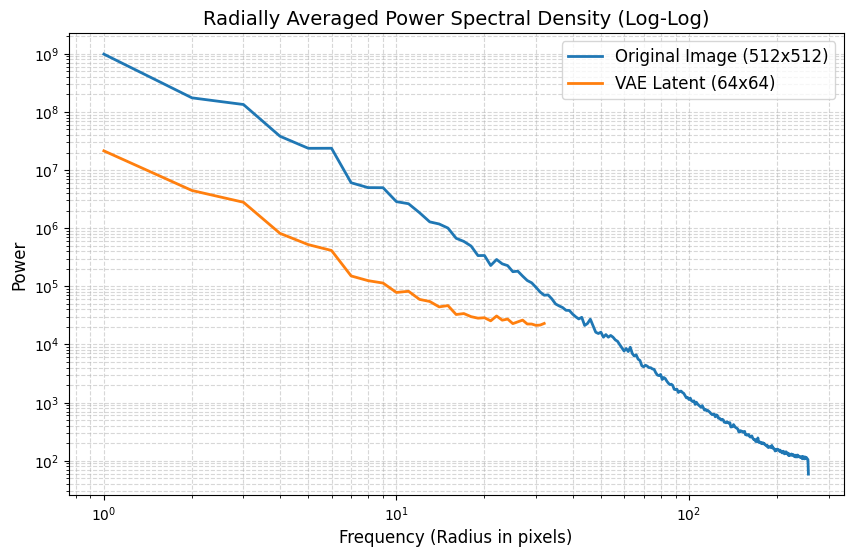

In [35]:
device = "mps"
print(f"Using device: {device}")

# A. Load the pretrained Stable Diffusion VAE
print("Loading VAE...")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval() # Set to evaluation mode

# B. Load a sample image (or use a local path: Image.open("my_image.jpg"))
image_path = "./images/000010.jpg"
img = Image.open(image_path).convert("RGB")

# C. Preprocess the image for the VAE
# VAEs typically expect tensors in the range [-1, 1]
transform = transforms.Compose([
    transforms.Resize((512, 512)), # SD VAEs like multiples of 8 (usually 512x512)
    transforms.ToTensor(),         # Converts to [0, 1]
    transforms.Normalize([0.5], [0.5]) # Shifts to [-1, 1]
])

img_tensor = transform(img).unsqueeze(0).to(device) # Shape: (1, 3, 512, 512)

# E. Encode the image through the VAE
print("Encoding Image...")
with torch.no_grad():
    # The VAE outputs a distribution. We take the mean (mode) for deterministic latents.
    posterior = vae.encode(img_tensor).latent_dist
    latents = posterior.mode() 
    
    # Note: SD latents are scaled by a constant (usually 0.18215) in the diffusion process,
    # but for purely checking the spectrum shape of the raw latent, we don't strictly need it.
    # latents shape: (1, 4, 64, 64) - note how H and W are 8x smaller!
    # latents = latents * 0.18215

print(f"Image shape: {img_tensor.shape}")
print(f"Latent shape: {latents.shape}")

psd_image = radial_power_spectrum(img_tensor)
psd_latent = radial_power_spectrum(latents)

# Plot them together!
plot_dict = {
    "Original Image (512x512)": psd_image,
    "VAE Latent (64x64)": psd_latent
}

plot_multiple_psd_1d(plot_dict)

#### The paper's hypothesis is that the VAE's latent space has a different PSD than the original image, especially for higher frequencies. 
#### Looking at the right side of the orange line (between X-axis values $10^1$ and $30$), the latent PSD line flattens out. It stops dropping and turns into a slightly jagged, horizontal line, which corresponds to power spectra of random noise.
#### This flattening means that the VAE isn't storing high frequencies (clean, structured details), it is storing unstructured, uncorrelated noise. 
#### The paper's "Encoding Spectrum Matching" (ESM) aims to fix this. By applying the ESM loss during training, that orange line would be forced to continue sloping downward smoothly, preserving the structural hierarchy of the data rather than devolving into static at the edges.